In [45]:
import numpy as np
import matplotlib.pyplot as plt 
import jax.numpy as jnp
import jax
import pandas as pd

In [46]:
import pandas as pd

data = pd.read_csv('../fictious_data.csv')

print(data.shape) #(rows,columns)

data.head() ## Prints the first few rows of the dataframe

(212, 2)


,date,count
0,2025-10-01,3
1,2025-10-02,7
2,2025-10-03,3
3,2025-10-04,4
4,2025-10-05,10


### Optimization

In 1 and 2 dimensional parameter spaces we can often do this grid search to find optimal parameter values. However in higher dimensions performing a grid search becomes extremely costly. We therefore need smarter techniques for identifying the minimum of our loss function. 

Many techniques exist for optimizing loss functions, including metaheuristic algorithms like Particle Swarm Optimization or Ant Colony Optimization. In addition, machine learning commonly makes use of differentiable loss functions whose gradients can be used to make intelligent steps. 

Instead of identifying minimum values in a single step, many optimization algorithms take small steps in the parameter space until some convergence criteria is reached. As an illustrative example we will now consider gradient descent. 

#### Gradient Descent

Gradient descent is a technique for finding the minimums of functions which involves taking many small steps in the direction of steepest descent. Mathematically we write 

$$
\theta_{n+1} = \theta_{n} - \eta \nabla \mathcal{L}(\theta_{n})
$$

Where $\theta_{n}$ is the current best guess for the parameters which minimize $\mathcal{L}$, $\eta$ is a parameter that controls the step size, and $\nabla \mathcal{L}(\theta_{n})$ is a vector called the gradient. The gradient is defined as 

$\nabla \mathcal{L}(\theta) = [\frac{\partial \mathcal{L}}{\partial \theta^{1}},\dots,\frac{\partial \mathcal{L}}{\partial \theta^{k}}]$ where the index of $\theta^{i}$ ranges from $0$ to $k$. 

The idea of the gradient is that for any scalar function the gradient tells us the direction to move to increase the value of the function as quickly as possible. 

For example, take the function $f(x,y) = e^{-(x^2 + y^2)}$ plotted below. 

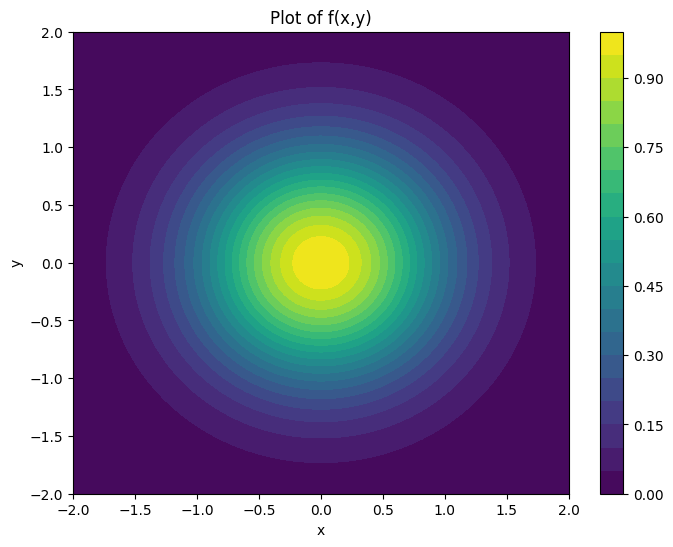

In [47]:
spacing = 0.01
plt.figure(figsize=(8, 6))
plt.title('Plot of f(x,y)')

xy_range = np.arange(-2, 2 + spacing, spacing)
X, Y = np.meshgrid(xy_range, xy_range)
plt.contourf(X, Y, np.exp(-(X**2 + Y**2)), cmap='viridis',levels = 20)

plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

We can see this function has a maximum at $(0,0)$. Suppose we have are starting at a point $(1,2)$ and we want to take a series of small steps towards the maximum. We can compute the gradient 

$$
\begin{align*}
\nabla \mathcal{f}(x,y) &= \left[\frac{\partial f}{\partial x},\frac{\partial f}{\partial y}\right] \\
&= \left[\frac{\partial}{\partial x}\left(e^{-(x^2 + y^2)}\right),\frac{\partial}{\partial y}\left(e^{-(x^2 + y^2)}\right) \right] \\
&= \left[-2x e^{-(x^2 + y^2)},-2y e^{-(x^2 + y^2)}\right].
\end{align*}
$$

This gives us a vector for each point in the domain of $f$. If we take a step along that vector we will increase the function value as quickly as possible. Let's visualize this.

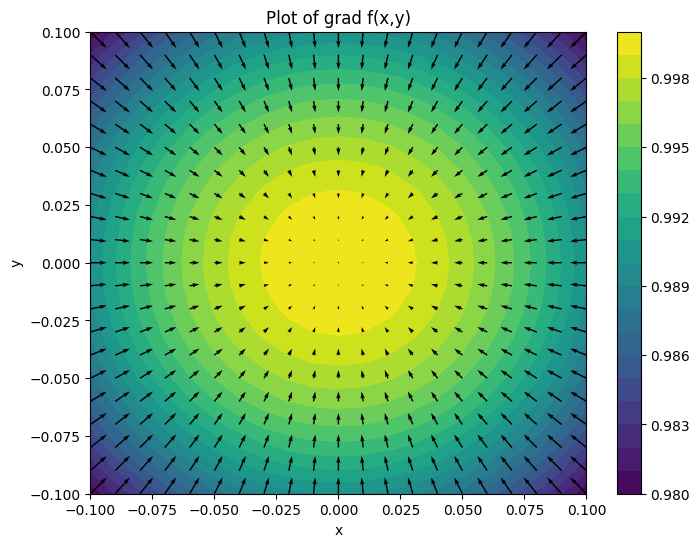

In [48]:
plt.figure(figsize=(8, 6))
plt.title("Plot of grad f(x,y)")

def grad_f(x, y):
    return np.array([-2 * x * np.exp(-(x**2 + y**2)), -2 * y * np.exp(-(x**2 + y**2))])

xy_range = np.arange(-0.1, 0.1 + spacing, spacing)
X, Y = np.meshgrid(xy_range, xy_range)
plt.contourf(X, Y, np.exp(-(X**2 + Y**2)), cmap="viridis", levels=20)
plt.colorbar()
U,V = grad_f(X,Y)
plt.quiver(X,Y,U,V)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

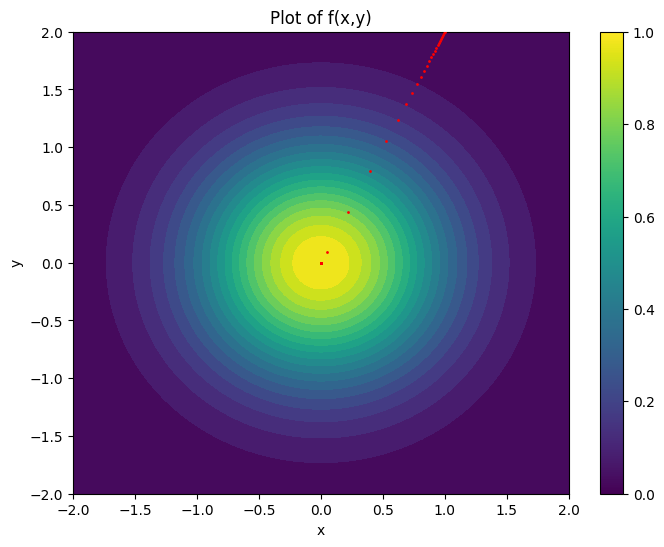

In [49]:
steps = 50
step_size = 0.5

points_visited = np.zeros((steps, 2))
points_visited[0, :] = np.array([1.0, 2.0])
for step in range(1, steps):
    prev_point = points_visited[step - 1, :]
    curr_point = prev_point + step_size * grad_f(prev_point[0], prev_point[1])
    points_visited[step, :] = curr_point

plt.figure(figsize=(8, 6))
plt.title("Plot of f(x,y)")

xy_range = np.arange(-2, 2 + spacing, spacing)
X, Y = np.meshgrid(xy_range, xy_range)
plt.contourf(X, Y, np.exp(-(X**2 + Y**2)), cmap="viridis", levels=20)
plt.scatter(points_visited[:, 0], points_visited[:, 1], color="red", zorder=100,s=1.0)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Let's try this on another slightly more complicated function. This function illustrates an issue with gradient descent, that if there are multiple local optima gradient descent can get stuck in one. 


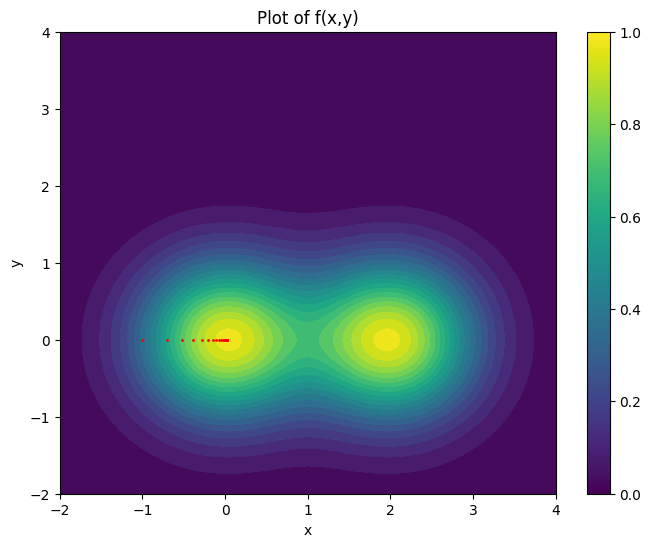

In [50]:
def f(x, y):
    return np.exp(-(x**2 + y**2)) + np.exp(-((x - 2) ** 2 + y**2))


steps = 20
step_size = 0.1

def grad_f(x, y):
    return np.array(
        [
            2
            * np.exp(-(y**2))
            * (-np.exp(-((x + 2) ** 2)) * (x - 2) - x * np.exp(-(x**2))),
            -2 * np.exp(-4 - x**2 - y**2) * (np.exp(4) + np.exp(4 * x)) * y,
        ]
    )


points_visited = np.zeros((steps, 2))
points_visited[0, :] = np.array([-1.0, 0.0])
for step in range(1, steps):
    prev_point = points_visited[step - 1, :]
    curr_point = prev_point + step_size * grad_f(prev_point[0], prev_point[1])
    points_visited[step, :] = curr_point

plt.figure(figsize=(8, 6))
plt.title("Plot of f(x,y)")

xy_range = np.arange(-2, 4 + spacing, spacing)
X, Y = np.meshgrid(xy_range, xy_range)
vals = f(X, Y)
plt.contourf(X, Y, vals, 20)
plt.scatter(points_visited[:, 0], points_visited[:, 1], color="red", zorder=100, s=1.0)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

By taking steps in the direction of the gradient we approach the maximum of our function. This technique is highly effective, however it requires manually calcuating the gradient for each function we want to optimize. For our loss function $\mathcal{L}$ this is clearly not possible. 

### Automatic Differentiation
Using modern machine learning libraries we can differentiate functions that are written in python with only a few lines of code. We will use the JAX library which can serve as a drop in replacement for NumPy where all the operations are differentiable.  

In [51]:
def sir_rhs(X,params):
    S,I,R = X
    N = S + I + R
    beta,gamma = params 
    dS = -beta * S * I/N
    dI = beta * S * I/N - gamma * I
    dR = gamma * I
    return jnp.array([dS,dI,dR])


def model(rhs,x0,ts,par):
    delta_t = ts[1]-ts[0] 

    def scan_fn(carry,t_index): 
        x_prev = carry
        x_curr = x_prev + delta_t * rhs(x_prev,par)
        return x_curr,x_curr

    _,ys = jax.lax.scan(scan_fn,init = x0,xs = ts)

    return ys

In [52]:
def loss(par_prop,data):
    x0 = jnp.array([495.,5.,0.])
    delta_t = 0.01
    ts = jnp.arange(0,len(data),delta_t)
    sol_prop = model(sir_rhs,x0,ts,par_prop)
    return jnp.sum((data - sol_prop[::int(1/delta_t),1])**2) 

numpy_data = data['count'].to_numpy()

loss((0.3,0.1),numpy_data)

Array(355574.1, dtype=float32)

In [53]:
loss_grad = jax.grad(loss)
loss_grad((0.3,0.1),numpy_data)

(Array(2.455935e+06, dtype=float32, weak_type=True),
 Array(-8.666227e+06, dtype=float32, weak_type=True))

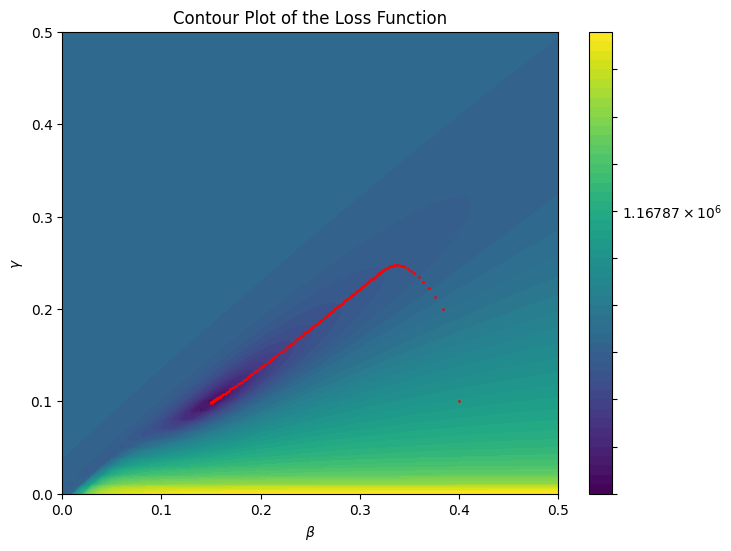

Optimal Param Estimate: [0.14965545 0.09865821]


In [56]:
from matplotlib.colors import LogNorm

steps = 150
step_size = 1e-8
param_range = np.arange(0, 0.5 + spacing, spacing)
B, G = np.meshgrid(param_range, param_range)
BG_stacked = jnp.concatenate((G[..., None], B[..., None]), axis=-1)
loss_vals = jax.vmap(jax.vmap(loss, in_axes=(0, None)), in_axes=(1, None))(
    BG_stacked, numpy_data
)

points_visited = np.zeros((steps, 2))
points_visited[0, :] = np.array([0.4, 0.1])
for step in range(1, steps):
    prev_point = points_visited[step - 1, :]
    curr_point = prev_point - step_size * loss_grad(prev_point, numpy_data)
    points_visited[step, :] = curr_point

plt.figure(figsize=(8, 6))

plt.contourf(
    B,
    G,
    loss_vals,
    levels=np.logspace(np.log10(loss_vals.min()), np.log10(loss_vals.max()), 50),
    norm=LogNorm(),
    cmap="viridis",
)

plt.colorbar()
plt.scatter(points_visited[:, 0], points_visited[:, 1], color="red", zorder=100, s=1.0)

plt.title("Contour Plot of the Loss Function")
plt.xlabel(r"$\beta$")
plt.ylabel(r"$\gamma$")
plt.show()

print(f"Optimal Param Estimate: {points_visited[-1]}")

We can see our algorithm iteratively approaches the minimum of the function as long as our step along the gradient is sufficiently small. 